In [1]:
import os
import sys
from pathlib import Path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO
from cv_utils import *
from cv_pipeline import *

In [2]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
pitch_segment_model = smp.Unet("resnet34", encoder_weights="imagenet", activation=None, classes=7)
pitch_segment_model.load_state_dict(torch.load(os.path.join(model_path, "res_unet_512.pth")))

player_detect_model = YOLO(os.path.join(model_path, "yolov8n_2nd_train.pt"))

data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name = 'Fifa game 1'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

D:\Football-analysis\src\cv_utils.py:191: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  predicted_mask = F.softmax(predicted_mask)

0: 576x1024 24 persons, 60.0ms
Speed: 8.0ms preprocess, 60.0ms inference, 4.0ms postprocess per image at shape (1, 3, 576, 1024)
C:\Users\User\anaconda3\envs\football\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\User\anaconda3\envs\football\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[{'idx': 5, 'box': [1334, 720, 1371, 829]}, {'idx': 7, 'box': [1865, 702, 1916, 815]}, {'idx': 8, 'box': [2215, 266, 2252, 348]}, {'idx': 9, 'box': [2376, 528, 2419, 629]}, {'idx': 15, 'box': [2376, 396, 2413, 481]}, {'idx': 16, 'box': [2445, 692, 2485, 800]}, {'idx': 17, 'box': [1855, 255, 1892, 346]}, {'idx': 20, 'box': [1321, 253, 1357, 336]}]
[{'idx': 1, 'box': [1206, 171, 1240, 260]}, {'idx': 2, 'box': [757, 451, 792, 554]}, {'idx': 3, 'box': [296, 597, 335, 699]}, {'idx': 4, 'box': [465, 342, 500, 431]}, {'idx': 6, 'box': [104, 286, 164, 373]}, {'idx': 10, 'box': [1274, 422, 1313, 548]}, {'idx': 11, 'box': [559, 33, 594, 115]}, {'idx': 12, 'box': [1202, 846, 1243, 948]}]
Team 1: {'player_104_286_164_373': 1, 'player_296_597_335_699': 2, 'player_465_342_500_431': 3, 'player_559_33_594_115': 4, 'player_757_451_792_554': 5, 'player_1202_846_1243_948': 6, 'player_1206_171_1240_260': 7, 'player_1274_422_1313_548': 8}
Team 2: {'player_1321_253_1357_336': 1, 'player_1334_720_1371_829': 

D:\Football-analysis\src\cv_utils.py:191: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  predicted_mask = F.softmax(predicted_mask)

0: 576x1024 24 persons, 1 ball, 58.9ms
Speed: 9.1ms preprocess, 58.9ms inference, 4.0ms postprocess per image at shape (1, 3, 576, 1024)
C:\Users\User\anaconda3\envs\football\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[{'idx': 5, 'box': [2395, 554, 2458, 633]}, {'idx': 6, 'box': [1871, 276, 1908, 356]}, {'idx': 8, 'box': [1832, 418, 1878, 489]}, {'idx': 10, 'box': [2254, 278, 2289, 357]}, {'idx': 13, 'box': [2409, 399, 2453, 484]}, {'idx': 15, 'box': [1851, 739, 1897, 839]}, {'idx': 16, 'box': [1342, 693, 1393, 805]}, {'idx': 17, 'box': [2500, 713, 2538, 807]}, {'idx': 19, 'box': [2019, 531, 2052, 647]}]
[{'idx': 0, 'box': [211, 295, 250, 380]}, {'idx': 1, 'box': [856, 470, 895, 565]}, {'idx': 2, 'box': [563, 350, 612, 437]}, {'idx': 3, 'box': [426, 597, 476, 692]}, {'idx': 4, 'box': [1330, 433, 1365, 536]}, {'idx': 7, 'box': [1338, 878, 1376, 992]}, {'idx': 11, 'box': [646, 42, 688, 127]}, {'idx': 12, 'box': [67, 1212, 124, 1346]}, {'idx': 14, 'box': [1297, 185, 1340, 263]}]
Team 1: {'player_67_1212_124_1346': 1, 'player_211_295_250_380': 2, 'player_426_597_476_692': 3, 'player_563_350_612_437': 4, 'player_646_42_688_127': 5, 'player_856_470_895_565': 6, 'player_1297_185_1340_263': 7, 'player_1330_

D:\Football-analysis\src\cv_utils.py:191: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  predicted_mask = F.softmax(predicted_mask)

0: 576x1024 22 persons, 59.0ms
Speed: 8.0ms preprocess, 59.0ms inference, 5.0ms postprocess per image at shape (1, 3, 576, 1024)
C:\Users\User\anaconda3\envs\football\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[{'idx': 2, 'box': [1331, 230, 1369, 309]}, {'idx': 5, 'box': [2367, 262, 2409, 344]}, {'idx': 7, 'box': [1943, 778, 1994, 885]}, {'idx': 8, 'box': [2492, 400, 2529, 487]}, {'idx': 9, 'box': [1387, 632, 1435, 723]}, {'idx': 10, 'box': [1898, 436, 1937, 523]}, {'idx': 14, 'box': [1925, 285, 1969, 375]}, {'idx': 16, 'box': [2298, 557, 2343, 641]}]
[{'idx': 0, 'box': [1251, 467, 1295, 560]}, {'idx': 1, 'box': [903, 334, 953, 422]}, {'idx': 3, 'box': [934, 611, 978, 716]}, {'idx': 4, 'box': [273, 705, 315, 819]}, {'idx': 6, 'box': [560, 288, 599, 376]}, {'idx': 11, 'box': [1806, 897, 1866, 1009]}, {'idx': 12, 'box': [1721, 434, 1757, 529]}, {'idx': 13, 'box': [1617, 158, 1657, 247]}]
Team 1: {'player_273_705_315_819': 1, 'player_560_288_599_376': 2, 'player_903_334_953_422': 3, 'player_925_31_964_112': 4, 'player_934_611_978_716': 5, 'player_1251_467_1295_560': 6, 'player_1617_158_1657_247': 7, 'player_1721_434_1757_529': 8, 'player_1806_897_1866_1009': 9}
Team 2: {'player_1331_230_1369_30

<Figure size 2400x1800 with 0 Axes>

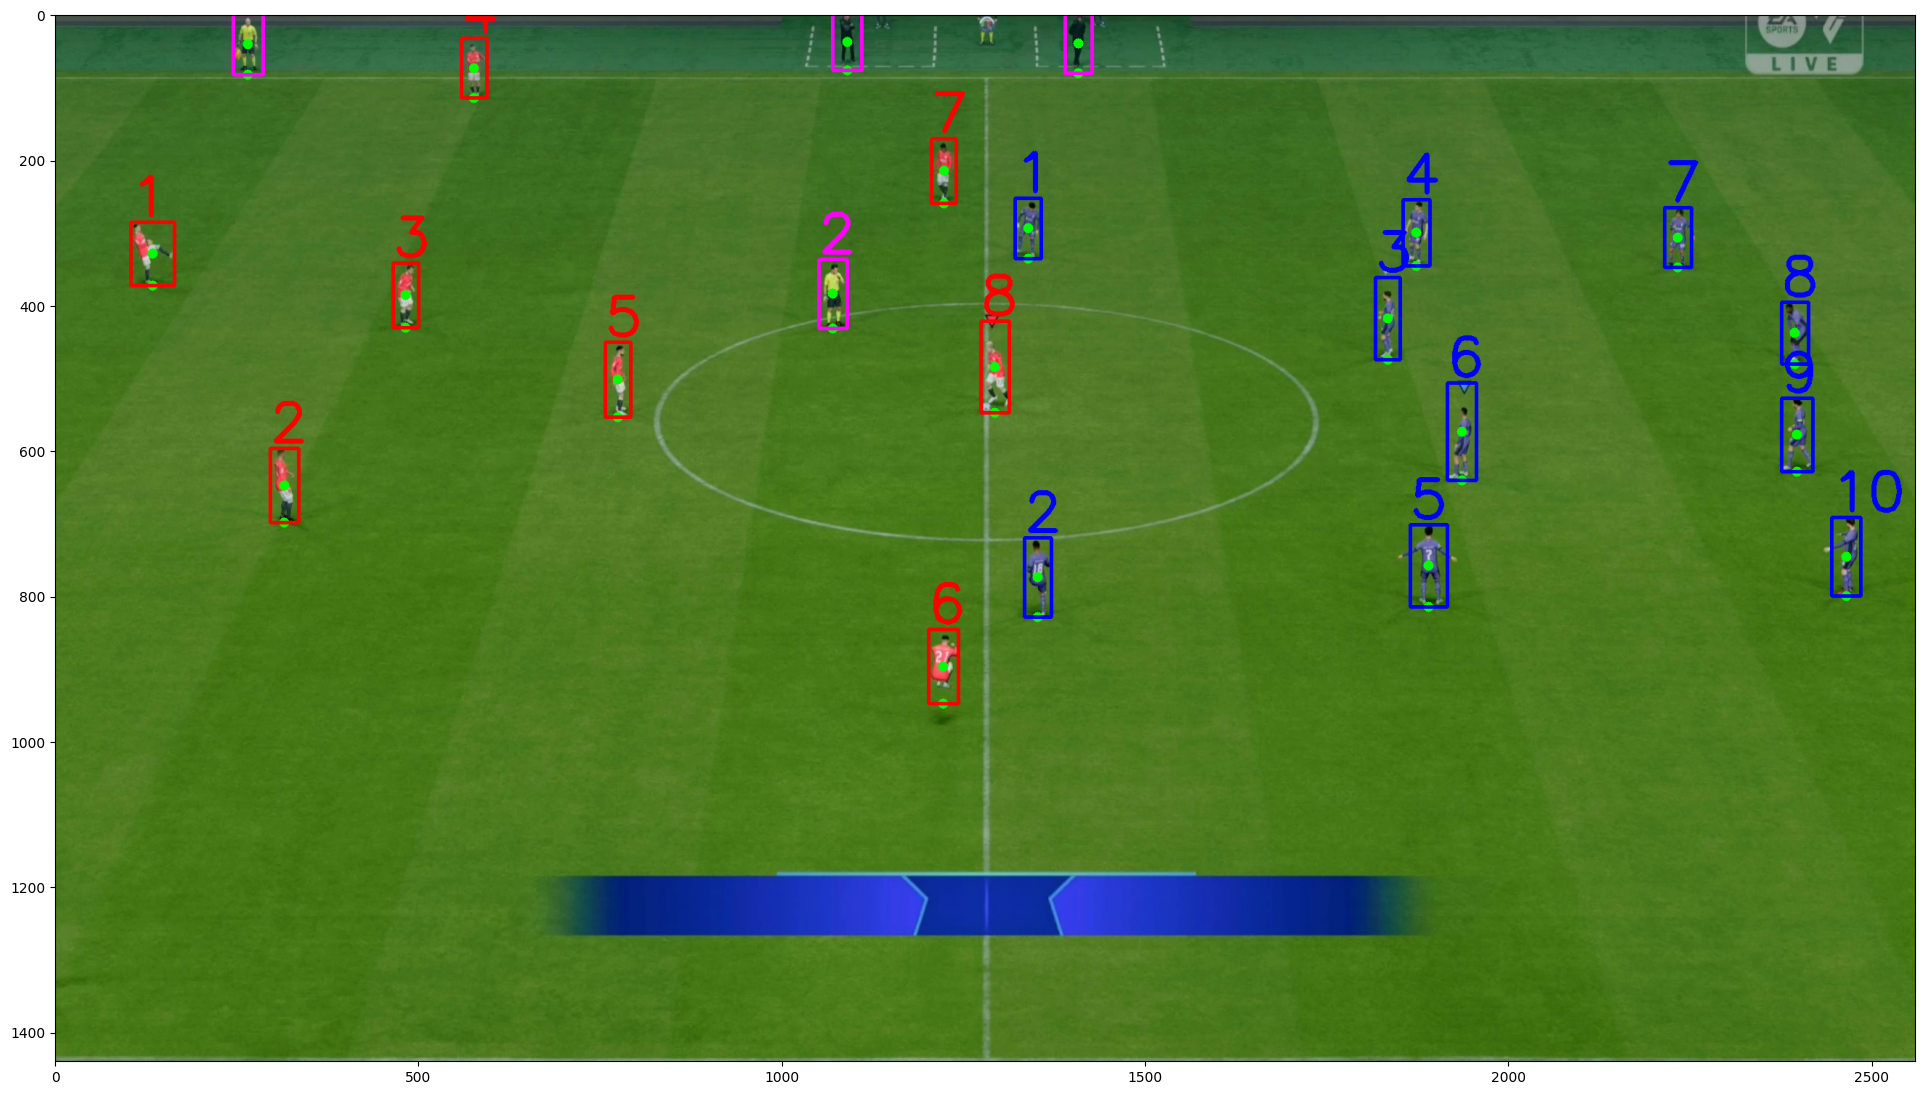

<Figure size 2400x1800 with 0 Axes>

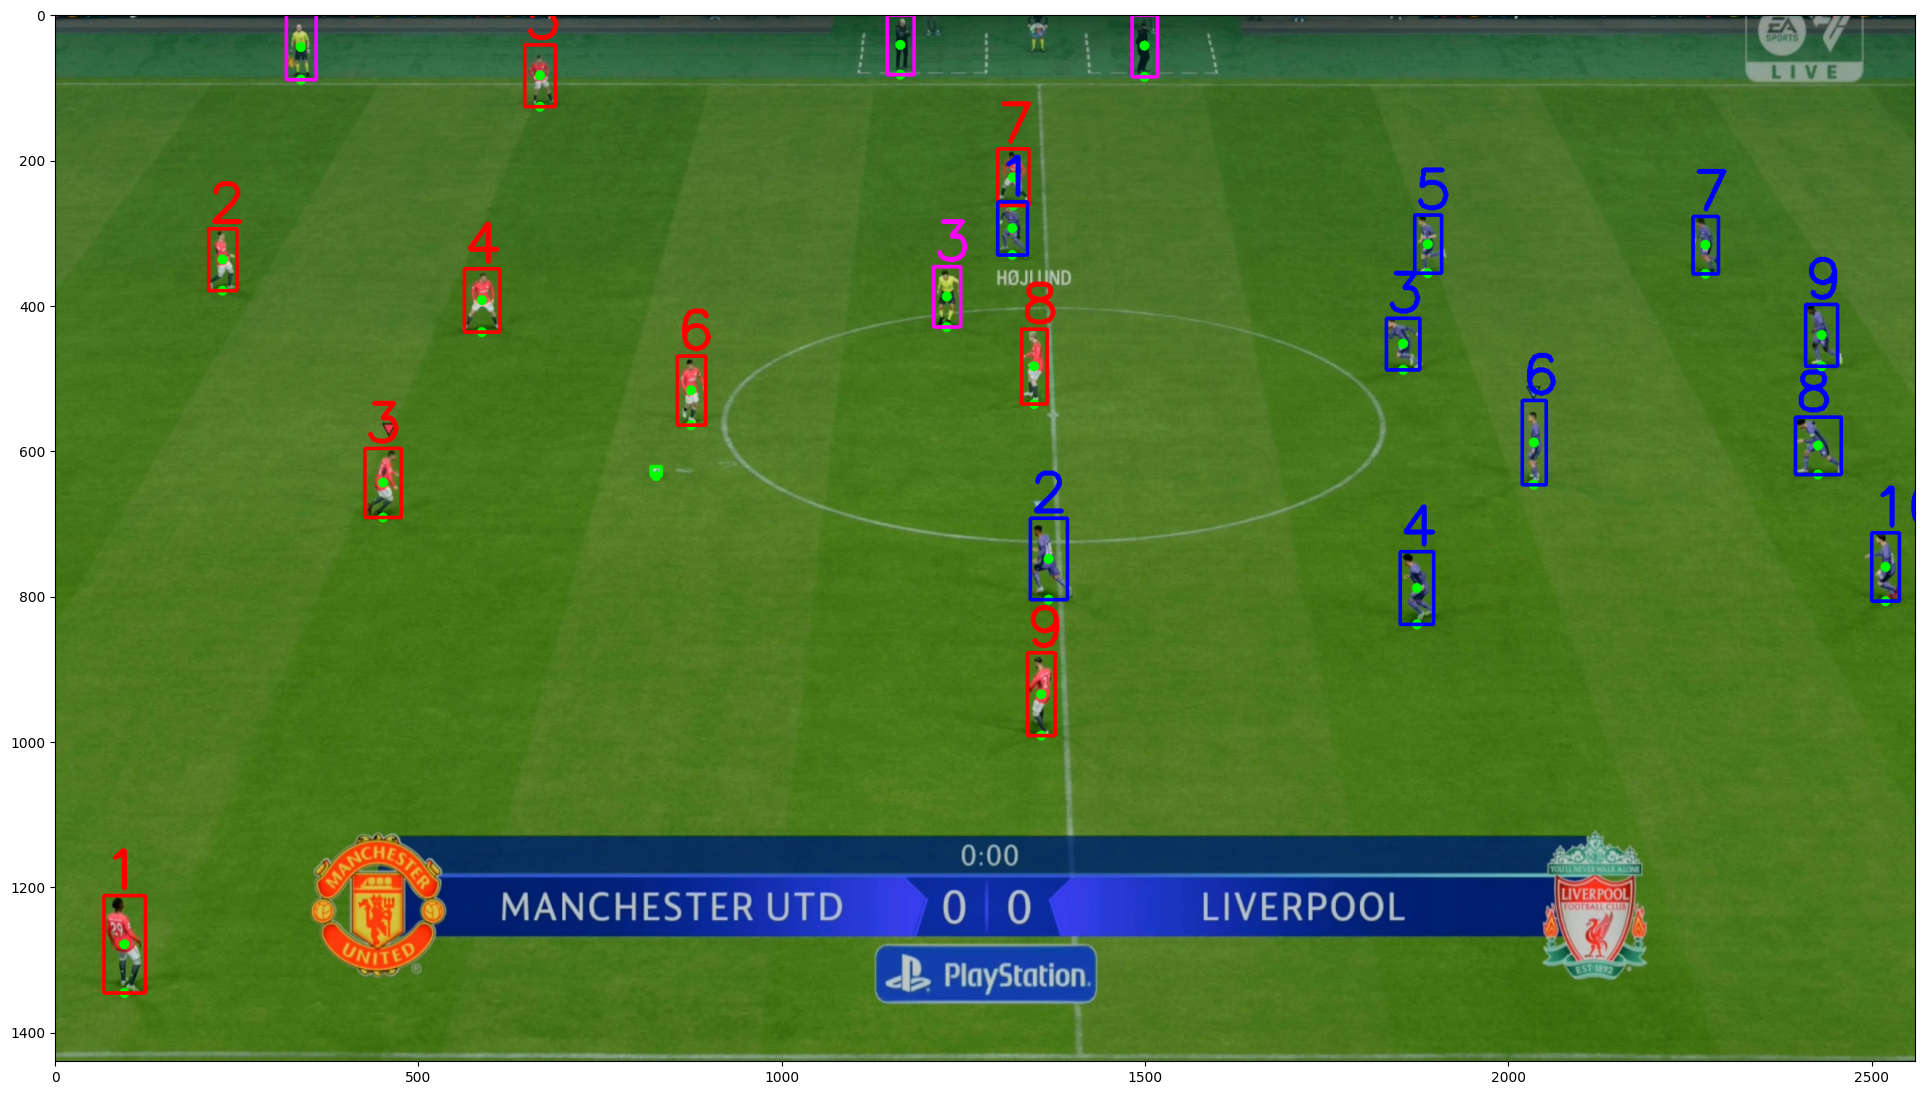

<Figure size 2400x1800 with 0 Axes>

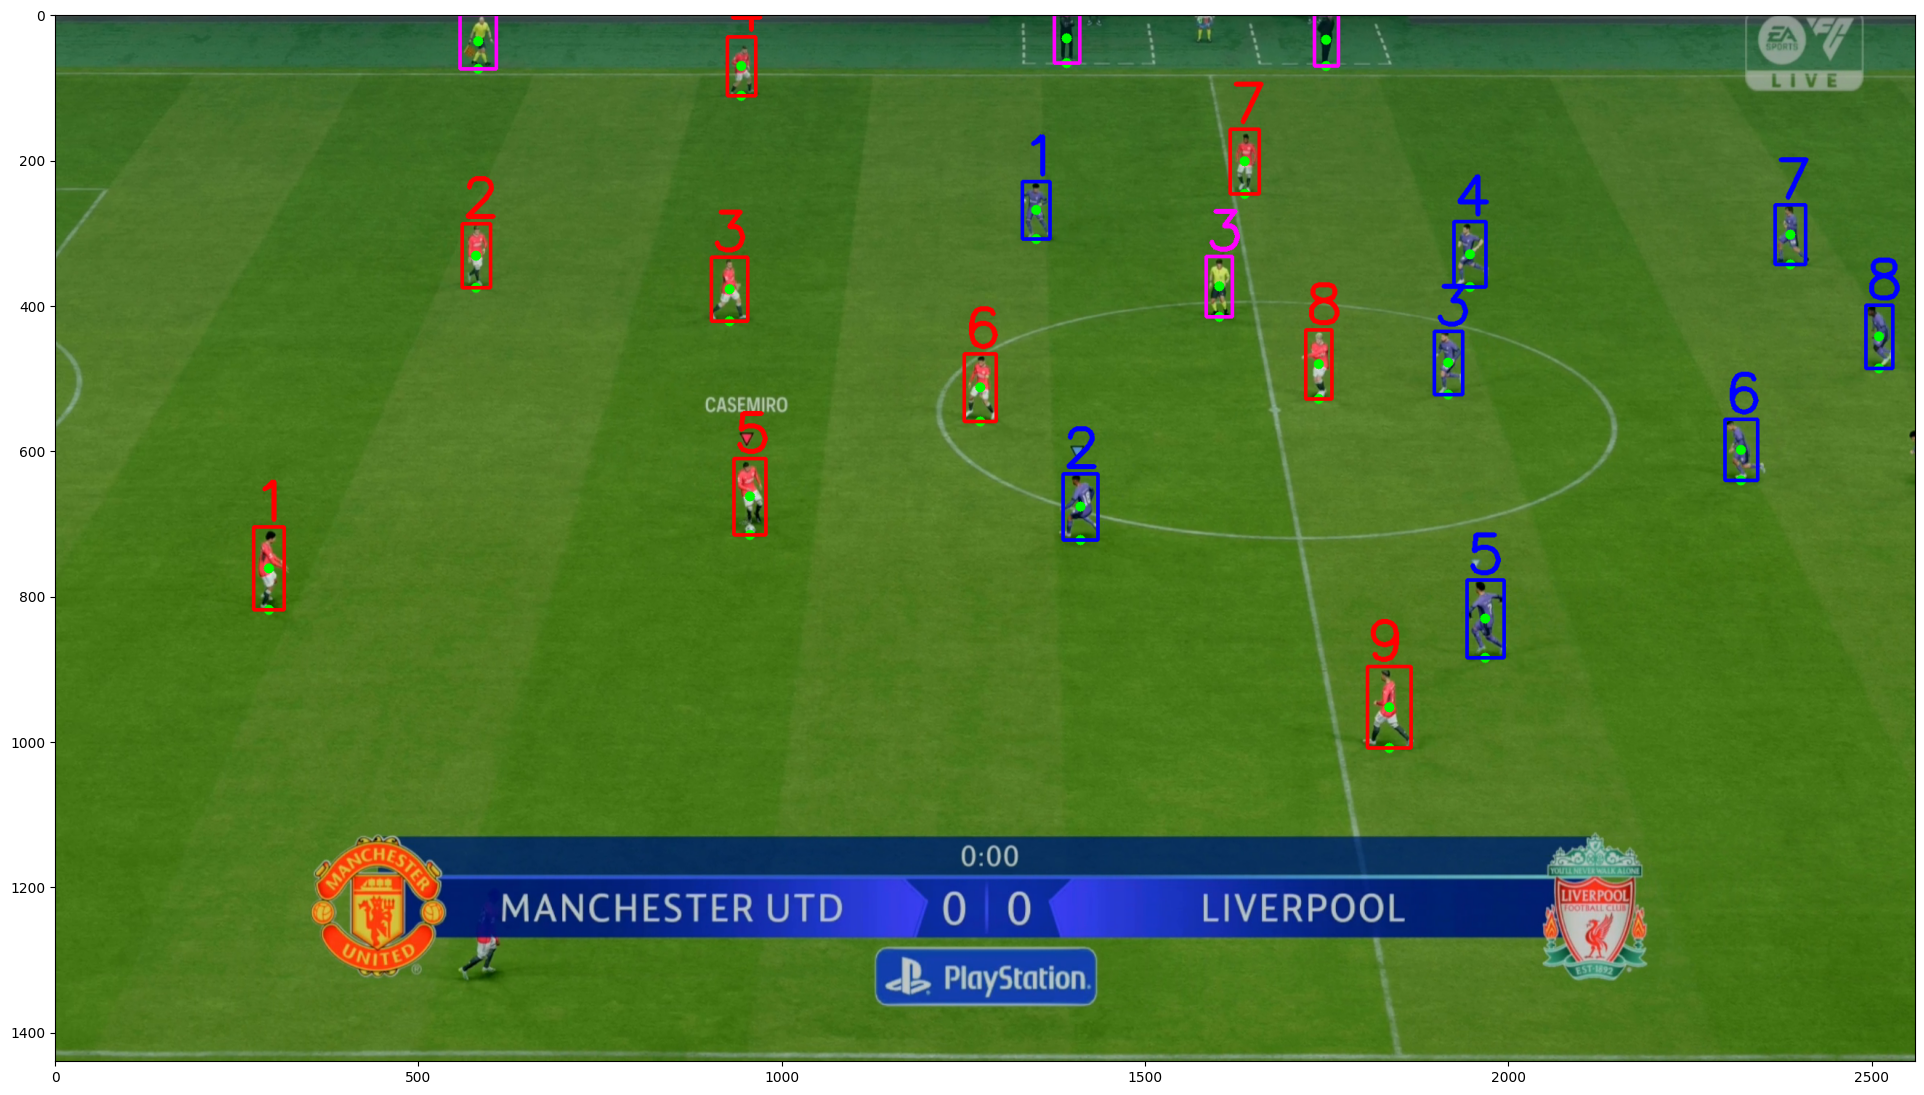

In [8]:
def calculate_distance(box1, box2):
    """
    Calculate the Euclidean distance between the centers of two bounding boxes.
    """
    center1 = np.array([(box1[0] + box1[2]) / 2, (box1[1] + box1[3]) / 2])
    center2 = np.array([(box2[0] + box2[2]) / 2, (box2[1] + box2[3]) / 2])
    return np.linalg.norm(center1 - center2)


for frame_id in range(3):
    tracking_dict = {}
    # TODO: them 2 attribute: home_id, away_id, chua bounding box thuoc ve team do
    # home = {home_id: 1, bounding_box: bounding_box_home, box_coord}
    formation_dict = {'home_formation' : '433',
                    'home_position' : [22, 35, 6, 2, 4, 41, 20, 8, 19, 14, 9],
                    'home_color' : np.nan, 
                    'away_formation' : '433',
                    'away_position' : [31, 24, 6, 3, 2, 8, 20, 82, 47, 9, 19],
                    'away_color' : np.nan}

    # Load image
    frame = cv2.imread(os.path.join(images_path, sorted(os.listdir(images_path))[frame_id]),
                            cv2.IMREAD_UNCHANGED)
    orig_w, orig_h = frame.shape[:2]

    # Crop image to pitch by model
    predicted_mask, colored_mask = pitch_segment(frame, pitch_segment_model, device='cpu')
    pitch_area = cv2.inRange(predicted_mask, 41, 43)
    contours, rect, hull = detect_largest_contour(pitch_area)

    mask = np.zeros_like(frame)
    cv2.fillPoly(mask, [hull], (255, 255, 255))
    grass_mask = cv2.bitwise_and(frame, mask)

    startX, startY, w, h = rect
    endX, endY = startX + w, startY + h
    frame = cv2.resize(frame[startY:endY, startX:endX], (orig_h, orig_w))
    grass_mask = cv2.resize(grass_mask[startY:endY, startX:endX], (orig_h, orig_w))
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    grass_mask = cv2.cvtColor(grass_mask, cv2.COLOR_BGR2RGB)
    plt.figure()
    # plt.imshow(frame)

    # Detect players on the field
    player_box_list, ball_box = model_predict(player_detect_model, frame)
    if len(player_box_list) < 8:
        continue

    # Filter obscured player boxes
    player_box_list = filter_boxes_by_obscurity(player_box_list, threshold=20)

    # Filter out players from image to get grass color
    for box in player_box_list:
        cv2.rectangle(grass_mask, (box[0], box[1]), (box[2], box[3]),
                        (0, 0, 0), -1)

    # Differentiate teams by color
    color_list = player_color_from_frame(player_box_list, frame, grass_mask)
    if frame_id == 0:
        team_1_color, team_2_color = get_teams_average_color(color_list)

    if team_1_color is None or team_2_color is None:
        print("dm Phi")

    team_1_idx, team_2_idx, misc_idx = fix_annotation_by_color(color_list, team_1_color,
                                                            team_2_color, threshold=40)
    team_1_box = [player_box_list[i] for i in team_1_idx]
    team_2_box = [player_box_list[i] for i in team_2_idx]
    misc_box = [player_box_list[i] for i in misc_idx]

    # Check within a team
    team_1_uncollided = [
        box 
            for i, box in enumerate(team_1_box) 
                if all(not in_collision(box, other_box) 
                    for other_box in team_1_box[:i] + team_1_box[i+1:])
    ]
    team_2_uncollided = [
        box 
            for i, box in enumerate(team_1_box) 
                if all(not in_collision(box, other_box) 
                    for other_box in team_1_box[:i] + team_1_box[i+1:])
    ]
    
    # Check between 2 teams
    team_1_uncollided = [a for a, b in zip(team_1_box, team_2_box) if not in_collision(a, b)]
    team_1_uncollided = [b for a, b in zip(team_1_box, team_2_box) if not in_collision(a, b)]
    
    # Check misc if collided with players
    misc_uncollided = [a for a, b in zip(misc_box, team_1_uncollided+team_2_uncollided) if not in_collision(a, b)]


    team_1_data = [team_1_idx, team_1_uncollided]
    team_2_data = [team_2_idx, team_2_uncollided]
    team_1_info = [
        {
            'idx': idx,
            'box': box_values,
        }
        for idx, box_values in zip(team_1_data[0], team_1_data[1])
    ]
    team_2_info = [
        {
            'idx': idx,
            'box': box_values,
        }
        for idx, box_values in zip(team_2_data[0], team_2_data[1])
    ]
    print(team_1_info)
    print(team_2_info)

    # Player tracking
    team_1_player_ids = {}
    
    for i, box in enumerate(sorted(team_1_box)):
        x, y, x2, y2 = box
        player_id = f"player_{x}_{y}_{x2}_{y2}"

        if player_id not in team_1_player_ids:
            team_1_player_ids[player_id] = len(team_1_player_ids) + 1
    print("Team 1:", team_1_player_ids)
    
    team_2_player_ids = {}
    for i, box in enumerate(sorted(team_2_box)):
        x, y, x2, y2 = box
        player_id = f"player_{x}_{y}_{x2}_{y2}"

        if player_id not in team_2_player_ids:
            team_2_player_ids[player_id] = len(team_2_player_ids) + 1
    print("Team 2:", team_2_player_ids)
    
    misc_player_ids = {}
    for i, box in enumerate(sorted(misc_box)):
        x, y, x2, y2 = box
        player_id = f"player_{x}_{y}_{x2}_{y2}"

        if player_id not in misc_player_ids:
            misc_player_ids[player_id] = len(misc_player_ids) + 1
    print("Misc:", misc_player_ids)
    
    # Compare bounding boxes between two consecutive frames

#     for player_id in team_1_player_ids.keys():
#         prev_box = team_1_box[frame_id - 1][team_1_box[frame_id - 1].index(player_id)]
#         current_box = team_1_box[frame_id][team_1_box[frame_id].index(player_id)]

#         distance = calculate_distance(prev_box, current_box)

#         # Check if the distance is below a certain threshold
#         if distance < 30:
#             print(f"Player {player_id} in team 1 is close in consecutive frames.")
#     # Compare bounding boxes between two consecutive frames for team 2

#     for player_id in team_2_player_ids.keys():
#         prev_box = team_2_box[frame_id - 1][team_2_box[frame_id - 1].index(player_id)]
#         current_box = team_2_box[frame_id][team_2_box[frame_id].index(player_id)]

#         distance = calculate_distance(prev_box, current_box)

#         # Check if the distance is below a certain threshold
#         if distance < 30:
#             print(f"Player {player_id} in team 2 is close in consecutive frames.")

#     # Compare bounding boxes between two consecutive frames for misc players

#     for player_id in misc_player_ids.keys():
#         prev_box = misc_box[frame_id - 1][misc_box[frame_id - 1].index(player_id)]
#         current_box = misc_box[frame_id][misc_box[frame_id].index(player_id)]

#         distance = calculate_distance(prev_box, current_box)

#         # Check if the distance is below a certain threshold
#         if distance < 30:
#             print(f"Player {player_id} in misc players is close in consecutive frames.")
            
    visualize_team_players(frame, team_1_box, team_2_box, misc_box, ball_box=ball_box, 
                           team_1_player_ids=team_1_player_ids, team_2_player_ids=team_2_player_ids, 
                           misc_player_ids=misc_player_ids)
    #     visualize_team_players(frame, team_1_box, team_2_box, misc_box, ball_box=ball_box)
    #     visualize_team_players(frame, team_1_uncollided, team_2_uncollided, misc_uncollided, ball_box=ball_box)
    #print(player_ids)
    # Pitch POI detection

    
    # Pitch coordinates mapping


    frame_id += 1
    # handle collision, 2 bounding box dinh nhau qua nhieu -> bo 2 box


In [ ]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
print(images_path)
image_path = os.path.join(images_path, os.listdir(images_path)[21])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

In [ ]:
frame_rate = 5
window_of_frames = []

for frame_number in range(frame_rate):
    image_path = os.path.join(images_path, os.listdir(images_path)[frame_number])
    rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
    window_of_frames.append(rgb_image)

    plt.figure()
    plt.imshow(rgb_image[:, :, ::-1])
    plt.show()

In [ ]:


center_coordinates_list = []
ball_center_coordinates_list = []
bottom_line_centers_list = []
results_list = []
for index, rgb_image in enumerate(window_of_frames):
    temp = rgb_image.copy()
    center_coordinates = []
    ball_center_coordinates = []
    bottom_line_centers = []

    results = model.predict(rgb_image)
    results_list.append(results)

    for result in results:
        boxes = result.boxes
        classes = result.names
        for box in boxes:
            coord = box.xyxy.cpu().detach().int().tolist()[0]
            class_id = box.cls[0].item()
            if class_id != 1.0:
                (startX, startY, endX, endY) = coord
                cv2.rectangle(temp, (startX, startY), (endX, endY), (255, 0, 0), 2)

                centerX, centerY = box_center(coord)
                center_coordinates.append((centerX, centerY))
                cv2.circle(temp, (centerX, centerY), 5, (0, 0, 255), -1)

                bottom_centerX, bottom_centerY = box_bottom_coord(coord)
                bottom_line_centers.append((bottom_centerX, bottom_centerY))
                cv2.circle(temp, (bottom_centerX, bottom_centerY), 5, (0, 255, 0), -1)

            else:
                (ball_startX, ball_startY, ball_endX, ball_endY) = coord
                cv2.rectangle(temp, (ball_startX, ball_startY), (ball_endX, ball_endY), (0, 0, 255), 2)

                ball_centerX, ball_centerY = box_center(coord)
                ball_center_coordinates.append((ball_centerX, ball_centerY))
                cv2.circle(temp, (ball_centerX, ball_centerY), 5, (255, 0, 0), 1)
        
    if index == 0 or index == len(window_of_frames) - 1:  
        for center_coord, bottom_center in zip(center_coordinates, bottom_line_centers):
            print("Center Coordinates:", center_coord)
            print("Bottom Line Center:", bottom_center)

        for ball_coord in ball_center_coordinates:
            print("Ball Center Coordinates:", ball_coord)
        plt.figure()
        plt.imshow(temp[:,:,::-1])
    center_coordinates_list.append(center_coordinates)
    ball_center_coordinates_list.append(ball_center_coordinates)
    bottom_line_centers_list.append(bottom_line_centers)

In [ ]:
for index, (results, rgb_image, center_coordinates, ball_center_coordinates, bottom_line_centers) in enumerate( \
    zip(results_list, window_of_frames, center_coordinates_list, ball_center_coordinates_list, bottom_line_centers_list)):
    distance_threshold = 20
    boxes_to_remove = []
    for i in range(len(center_coordinates)):
        for j in range(i + 1, len(center_coordinates)):
            distance = np.linalg.norm(np.array(center_coordinates[i]) - np.array(center_coordinates[j]))
            if distance < distance_threshold:
                boxes_to_remove.extend([i, j])

    new_boxes = [box for i, box in enumerate(results[0].boxes) if i not in boxes_to_remove]
    center_coordinates = []
    bottom_line_centers = []
    ball_center_coordinates = []

    temp = rgb_image.copy()
    for box in new_boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        class_id = box.cls[0].item()
        if class_id != 1.0:
            (startX, startY, endX, endY) = coord
            cv2.rectangle(temp, (startX, startY), (endX, endY), (255, 0, 0), 2)

            centerX = (startX + endX) // 2
            centerY = (startY + endY) // 2
            center_coordinates.append((centerX, centerY))
            cv2.circle(temp, (centerX, centerY), 5, (0, 0, 255), -1)

            bottom_centerX = (startX + endX) // 2
            bottom_centerY = endY
            bottom_line_centers.append((bottom_centerX, bottom_centerY))
            cv2.circle(temp, (bottom_centerX, bottom_centerY), 5, (0, 255, 0), -1)

        else:
            (ball_startX, ball_startY, ball_endX, ball_endY) = coord
            cv2.rectangle(temp, (ball_startX, ball_startY), (ball_endX, ball_endY), (0, 0, 255), 2)

            ball_centerX = (ball_startX + ball_endX) // 2
            centerY = (ball_startY + ball_endY) // 2
            ball_center_coordinates.append((ball_centerX, ball_centerY))
            cv2.circle(temp, (ball_centerX, ball_centerY), 5, (255, 0, 0), 1)
    if index == 0 or index == len(window_of_frames) - 1: 
        for center_coord, bottom_center in zip(center_coordinates, bottom_line_centers):
            print("Center Coordinates:", center_coord)
            print("Bottom Line Center:", bottom_center)

        for ball_coord in ball_center_coordinates:
            print("Ball Center Coordinates:", ball_coord)

        plt.figure()
        plt.imshow(temp[:, :, ::-1])
        plt.show()